# 02 — Otsu threshold baseline

In this notebook, I apply Otsu thresholding to my cropped SEM/BSE images to create a simple baseline pore segmentation method. I use this as a non-machine-learning comparison before moving on to the Random Forest and CNN approaches.

My aim here is to see how well a basic thresholding method can separate pore space from the rest of the image, and then compare the predicted masks and porosity values against my Weka-derived masks and `porosity_weka` results.

**Workflow:** load inventory → read cropped images and Weka masks → generate Otsu predictions → calculate porosity and segmentation metrics → save results → preview example outputs.

**Relevant course pages:**
- AI algorithms: https://cpomucl.github.io/GEOL0069-AI4EO/Chapter_1_AI_Algorithms.html
- Full-image rollout: https://cpomucl.github.io/GEOL0069-AI4EO/Chapter_1_rollout_3.html

**Notes**
- I use the cropped images from my inventory where available, because they match the masks and probability maps I prepared earlier.
- I need to make sure the predicted pore mask is the correct way round before measuring porosity, so the pore class is treated as foreground rather than background.
- I expect this baseline to be limited by shadows, grain boundaries, and polishing artefacts, so I will use it mainly as a reference point for later supervised models.


In [16]:
from pathlib import Path
import os
from google.colab import drive

drive.mount('/content/drive')

REPO_ROOT = Path('/content/drive/MyDrive/GEOL0069-sem-segmentation-project')

if not REPO_ROOT.exists():
    !git clone https://github.com/courtneylorabrown/GEOL0069-sem-segmentation-project "{REPO_ROOT}"

%cd /content/drive/MyDrive/GEOL0069-sem-segmentation-project

DATA_DIR = REPO_ROOT / 'data'
RAW_DIR = DATA_DIR / 'raw'
CROPPED_DIR = DATA_DIR / 'cropped'
MASK_DIR = DATA_DIR / 'masks_weka'
PROB_DIR = DATA_DIR / 'probability_maps'
META_DIR = DATA_DIR / 'metadata'
RESULTS_DIR = REPO_ROOT / 'results'
OTSU_MASK_DIR = RESULTS_DIR / 'otsu_masks'

for folder in [RAW_DIR, CROPPED_DIR, MASK_DIR, PROB_DIR, META_DIR, RESULTS_DIR, OTSU_MASK_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

INVENTORY_PATH = META_DIR / 'image_inventory.csv'

print("Inventory:", INVENTORY_PATH)
print("Cropped folder exists:", CROPPED_DIR.exists())
print("Mask folder exists:", MASK_DIR.exists())
print("Results folder exists:", RESULTS_DIR.exists())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/GEOL0069-sem-segmentation-project
Inventory: /content/drive/MyDrive/GEOL0069-sem-segmentation-project/data/metadata/image_inventory.csv
Cropped folder exists: True
Mask folder exists: True
Results folder exists: True


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from skimage.filters import threshold_multiotsu
from skimage.morphology import remove_small_objects, remove_small_holes
from sklearn.metrics import precision_score, recall_score, f1_score, jaccard_score


def read_gray(path):
    return np.array(Image.open(path).convert("L"))


def read_weka_mask(path):
    """
    Original Weka masks:
    dark pixels = pore
    Returns binary mask with pore = 1, non-pore = 0
    """
    arr = np.array(Image.open(path).convert("L"))
    return (arr < 128).astype(np.uint8)


def read_pred_mask(path):
    """
    Saved prediction masks:
    pore pixels are saved as white (255)
    Returns binary mask with pore = 1, non-pore = 0
    """
    arr = np.array(Image.open(path).convert("L"))
    return (arr > 0).astype(np.uint8)


def save_mask(mask, path):
    """
    Save prediction mask with pore = white, non-pore = black
    """
    Image.fromarray((mask * 255).astype(np.uint8)).save(path)


def porosity_percent(mask):
    return float(mask.mean() * 100.0)


def clean_binary(mask, min_size=8, hole_size=8):
    mask = mask.astype(bool)
    mask = remove_small_objects(mask, min_size=min_size)
    mask = remove_small_holes(mask, area_threshold=hole_size)
    return mask.astype(np.uint8)

def choose_otsu_mask(img, gt=None, expected_porosity=None, min_size=8, hole_size=8):
    """
    Multi-Otsu with 3 classes.
    Pores are always taken as the darkest class.
    This keeps the definition of pore consistent across all images.
    """
    thresholds = threshold_multiotsu(img, classes=3)
    regions = np.digitize(img, bins=thresholds)

    pred_darkest = clean_binary(regions == 0, min_size=min_size, hole_size=hole_size)

    return pred_darkest, float(thresholds[0]), "darkest_multiotsu_class"



def segmentation_scores(gt, pred):
    return {
        "iou": jaccard_score(gt.ravel(), pred.ravel(), zero_division=0),
        "precision": precision_score(gt.ravel(), pred.ravel(), zero_division=0),
        "recall": recall_score(gt.ravel(), pred.ravel(), zero_division=0),
        "f1": f1_score(gt.ravel(), pred.ravel(), zero_division=0),
    }


In [18]:
df = pd.read_csv(INVENTORY_PATH)

for col in ["raw_file", "cropped_file", "weka_mask", "probability_map", "split", "notes"]:
    if col in df.columns:
        df[col] = df[col].fillna("").astype(str)

df["porosity_weka"] = pd.to_numeric(df["porosity_weka"], errors="coerce")

display(df[["image_id", "actual_magnification", "cropped_file", "weka_mask", "porosity_weka"]])
print("Number of rows:", len(df))


,image_id,actual_magnification,cropped_file,weka_mask,porosity_weka
0,13064_05_17A_400X-8-83,400,13064_05_17A_400X-8-83cropped.tif,13064_05_17A_400X-8-83mask.tif,1.000000
1,13074_00_18A_400X-9-10,400,13074_00_18A_400X-9-10cropped.tif,13074_00_18A_400X-9-10mask.tif,0.070000
2,13123_00_21A_400X-9-59,400,13123_00_21A_400X-9-59cropped.tif,13123_00_21A_400X-9-59mask.tif,2.268000
3,R2_10,400,R2_10cropped.tif,R2_10mask.tif,0.000477
4,13064_05_17B_1000X-8-83,1000,13064_05_17B_1000X-8-83cropped.tif,13064_05_17B_1000X-8-83mask.tif,1.987000
5,13087_50_19B_1000X-9-23,1000,13087_50_19B_1000X-9-23cropped.tif,13087_50_19B_1000X-9-23mask.tif,1.830000
6,13103_60_20B_1000X-9-39,1000,13103_60_20B_1000X-9-39cropped.tif,13103_60_20B_1000X-9-39mask.tif,0.445000
7,13123_00_21B_1000X-9-59,1000,13123_00_21B_1000X-9-59cropped.tif,13123_00_21B_1000X-9-59mask.tif,1.500000
8,13064_05_17C_2000X-8-83,2000,13064_05_17C_2000X-8-83cropped.tif,13064_05_17C_2000X-8-83mask.tif,2.078000
9,13087_50_19C_2000X-9-23,2000,13087_50_19C_2000X-9-23cropped.tif,13087_50_19C_2000X-9-23mask.tif,3.567000


Number of rows: 16


In [19]:
from PIL import Image
import pandas as pd

df = pd.read_csv(INVENTORY_PATH)

print("Checking cropped image and mask sizes...\n")

for _, row in df.iterrows():
    image_id = str(row["image_id"]).strip()
    cropped_name = str(row.get("cropped_file", "")).strip()
    mask_name = str(row.get("weka_mask", "")).strip()

    if not cropped_name or not mask_name:
        print(f"{image_id}: skipped (missing cropped_file or weka_mask)")
        continue

    image_path = CROPPED_DIR / cropped_name
    mask_path = MASK_DIR / mask_name

    if not image_path.exists():
        print(f"{image_id}: cropped image not found -> {cropped_name}")
        continue

    if not mask_path.exists():
        print(f"{image_id}: mask not found -> {mask_name}")
        continue

    img_size = Image.open(image_path).size   # (width, height)
    mask_size = Image.open(mask_path).size

    if img_size != mask_size:
        print(f"MISMATCH -> {image_id}")
        print(f"  image: {cropped_name}  size={img_size}")
        print(f"  mask : {mask_name}     size={mask_size}\n")
    else:
        print(f"OK -> {image_id} size={img_size}")


Checking cropped image and mask sizes...

OK -> 13064_05_17A_400X-8-83 size=(1023, 883)
OK -> 13074_00_18A_400X-9-10 size=(1023, 882)
OK -> 13123_00_21A_400X-9-59 size=(1022, 881)
OK -> R2_10 size=(1270, 825)
OK -> 13064_05_17B_1000X-8-83 size=(1023, 770)
OK -> 13087_50_19B_1000X-9-23 size=(1023, 882)
OK -> 13103_60_20B_1000X-9-39 size=(1022, 878)
OK -> 13123_00_21B_1000X-9-59 size=(1023, 880)
OK -> 13064_05_17C_2000X-8-83 size=(1023, 883)
OK -> 13087_50_19C_2000X-9-23 size=(1022, 880)
OK -> 13138_10_22C_2000X-9-74 size=(1023, 882)
OK -> B3_2 size=(1278, 827)
OK -> 13064_05_17D_3000X-8-83 size=(1024, 883)
OK -> 13124_00_21D_3000X-9-60 size=(1021, 882)
OK -> 13150_20_23D_3000X-9-86 size=(1022, 882)
OK -> 13162_65_24D_3000X-10-8 size=(1018, 880)


In [24]:
records = []

for _, row in df.iterrows():
    image_id = str(row["image_id"]).strip()

    cropped_name = row["cropped_file"].strip() if "cropped_file" in row else ""
    raw_name = row["raw_file"].strip() if "raw_file" in row else ""
    mask_name = row["weka_mask"].strip() if "weka_mask" in row else ""

    if cropped_name:
        image_path = CROPPED_DIR / cropped_name
    elif raw_name:
        image_path = RAW_DIR / raw_name
    else:
        print(f"Skipping {image_id}: no image file listed in inventory.")
        continue

    if not image_path.exists():
        print(f"Skipping {image_id}: image file not found -> {image_path.name}")
        continue

    img = read_gray(image_path)

    gt = None
    if mask_name:
        mask_path = MASK_DIR / mask_name
        if mask_path.exists():
            gt = read_weka_mask(mask_path)

    pred, thr, polarity = choose_otsu_mask(
        img,
        gt=gt,
        expected_porosity=row["porosity_weka"],
        min_size=8,
        hole_size=8
    )

    pred_name = f"{image_id}_otsu_mask.png"
    pred_path = OTSU_MASK_DIR / pred_name
    save_mask(pred, pred_path)

    record = {
        "image_id": image_id,
        "actual_magnification": row["actual_magnification"],
        "image_file_used": image_path.name,
        "weka_mask_file": mask_name if mask_name else "",
        "pred_mask_file": pred_name,
        "threshold": float(thr),
        "polarity_used": polarity,
        "porosity_weka": row["porosity_weka"],
        "otsu_porosity": porosity_percent(pred),
    }

    if gt is not None:
        record.update(segmentation_scores(gt, pred))
    else:
        record.update({
            "iou": np.nan,
            "precision": np.nan,
            "recall": np.nan,
            "f1": np.nan,
        })

    records.append(record)

otsu_results = pd.DataFrame(records)

if not otsu_results.empty:
    otsu_results["abs_error"] = (
        otsu_results["otsu_porosity"] - otsu_results["porosity_weka"]
    ).abs()
    otsu_results = otsu_results.sort_values(
        ["actual_magnification", "image_id"]
    ).reset_index(drop=True)

display(otsu_results)
print("Processed images:", len(otsu_results))


,image_id,actual_magnification,image_file_used,weka_mask_file,pred_mask_file,threshold,polarity_used,porosity_weka,otsu_porosity,iou,precision,recall,f1,abs_error
0,13064_05_17A_400X-8-83,400,13064_05_17A_400X-8-83cropped.tif,13064_05_17A_400X-8-83mask.tif,13064_05_17A_400X-8-83_otsu_mask.png,82.0,darkest_multiotsu_class,1.000000,39.677453,0.025214,0.025214,1.000000,0.049188,38.677453
1,13074_00_18A_400X-9-10,400,13074_00_18A_400X-9-10cropped.tif,13074_00_18A_400X-9-10mask.tif,13074_00_18A_400X-9-10_otsu_mask.png,85.0,darkest_multiotsu_class,0.070000,36.893402,0.001911,0.001911,1.000000,0.003814,36.823402
2,13123_00_21A_400X-9-59,400,13123_00_21A_400X-9-59cropped.tif,13123_00_21A_400X-9-59mask.tif,13123_00_21A_400X-9-59_otsu_mask.png,74.0,darkest_multiotsu_class,2.268000,41.046800,0.055210,0.055212,0.999412,0.104642,38.778800
3,R2_10,400,R2_10cropped.tif,R2_10mask.tif,R2_10_otsu_mask.png,97.0,darkest_multiotsu_class,0.000477,34.815557,0.000014,0.000014,1.000000,0.000027,34.815080
4,13064_05_17B_1000X-8-83,1000,13064_05_17B_1000X-8-83cropped.tif,13064_05_17B_1000X-8-83mask.tif,13064_05_17B_1000X-8-83_otsu_mask.png,73.0,darkest_multiotsu_class,1.987000,44.278732,0.044881,0.044881,1.000000,0.085907,42.291732
5,13087_50_19B_1000X-9-23,1000,13087_50_19B_1000X-9-23cropped.tif,13087_50_19B_1000X-9-23mask.tif,13087_50_19B_1000X-9-23_otsu_mask.png,72.0,darkest_multiotsu_class,1.830000,41.715376,0.043872,0.043872,1.000000,0.084056,39.885376
6,13103_60_20B_1000X-9-39,1000,13103_60_20B_1000X-9-39cropped.tif,13103_60_20B_1000X-9-39mask.tif,13103_60_20B_1000X-9-39_otsu_mask.png,77.0,darkest_multiotsu_class,0.445000,48.665353,0.009153,0.009153,1.000000,0.018140,48.220353
7,13123_00_21B_1000X-9-59,1000,13123_00_21B_1000X-9-59cropped.tif,13123_00_21B_1000X-9-59mask.tif,13123_00_21B_1000X-9-59_otsu_mask.png,79.0,darkest_multiotsu_class,1.500000,43.277682,0.034666,0.034666,1.000000,0.067009,41.777682
8,13064_05_17C_2000X-8-83,2000,13064_05_17C_2000X-8-83cropped.tif,13064_05_17C_2000X-8-83mask.tif,13064_05_17C_2000X-8-83_otsu_mask.png,75.0,darkest_multiotsu_class,2.078000,41.933713,0.049563,0.049563,1.000000,0.094445,39.855713
9,13087_50_19C_2000X-9-23,2000,13087_50_19C_2000X-9-23cropped.tif,13087_50_19C_2000X-9-23mask.tif,13087_50_19C_2000X-9-23_otsu_mask.png,72.0,darkest_multiotsu_class,3.567000,42.745619,0.083439,0.083439,1.000000,0.154026,39.178619


Processed images: 16


Saved full results to: /content/drive/MyDrive/GEOL0069-sem-segmentation-project/results/otsu_results.csv
Saved summary to: /content/drive/MyDrive/GEOL0069-sem-segmentation-project/results/otsu_summary_by_magnification.csv


,actual_magnification,n_images,mean_weka_porosity,mean_otsu_porosity,mean_abs_error,mean_iou,mean_f1
0,400,4,0.834619,38.108303,37.273684,0.020587,0.039418
1,1000,4,1.440500,44.484286,43.043786,0.033143,0.063778
2,2000,4,2.104500,41.408520,39.304020,0.049875,0.094275
3,3000,4,2.418000,35.221248,32.803248,0.069995,0.128895


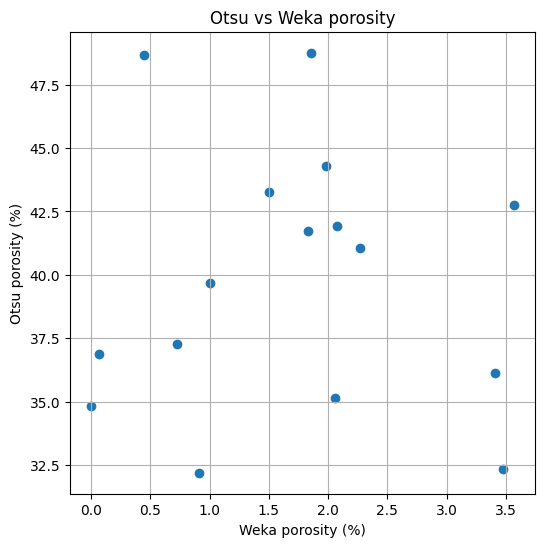

In [25]:
results_csv = RESULTS_DIR / "otsu_results.csv"
summary_csv = RESULTS_DIR / "otsu_summary_by_magnification.csv"

otsu_results.to_csv(results_csv, index=False)

summary = (
    otsu_results
    .groupby("actual_magnification", dropna=False)
    .agg(
        n_images=("image_id", "count"),
        mean_weka_porosity=("porosity_weka", "mean"),
        mean_otsu_porosity=("otsu_porosity", "mean"),
        mean_abs_error=("abs_error", "mean"),
        mean_iou=("iou", "mean"),
        mean_f1=("f1", "mean"),
    )
    .reset_index()
)

summary.to_csv(summary_csv, index=False)

print("Saved full results to:", results_csv)
print("Saved summary to:", summary_csv)

display(summary)

valid = otsu_results.dropna(subset=["porosity_weka"])

plt.figure(figsize=(6, 6))
plt.scatter(valid["porosity_weka"], valid["otsu_porosity"])
plt.xlabel("Weka porosity (%)")
plt.ylabel("Otsu porosity (%)")
plt.title("Otsu vs Weka porosity")
plt.grid(True)
plt.show()


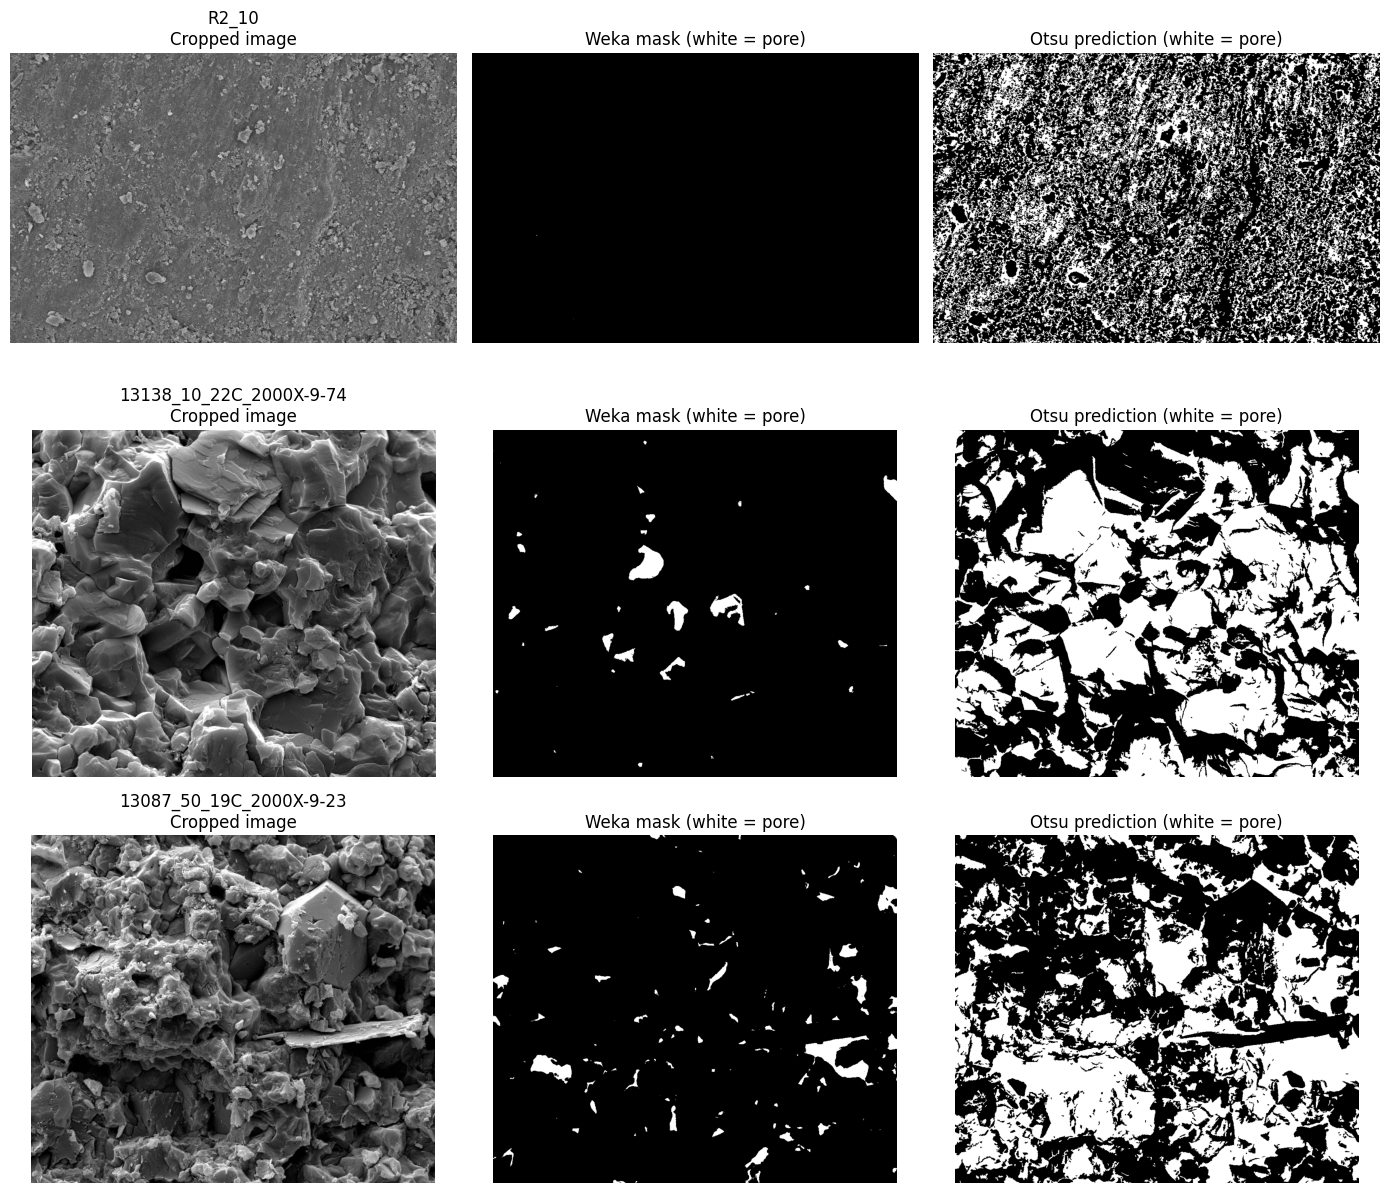

Selected images:
- R2_10
- 13138_10_22C_2000X-9-74
- 13087_50_19C_2000X-9-23


,image_id,actual_magnification,porosity_weka,otsu_porosity,iou,f1,polarity_used
0,R2_10,400,0.000477,34.815557,0.000014,0.000027,darkest_multiotsu_class
1,13138_10_22C_2000X-9-74,2000,1.860000,48.752169,0.038160,0.073515,darkest_multiotsu_class
2,13087_50_19C_2000X-9-23,2000,3.567000,42.745619,0.083439,0.154026,darkest_multiotsu_class


In [28]:
# Show 3 example images: low, middle, and high porosity
if len(otsu_results) > 0:
    view_df = otsu_results.copy()

    # Bring in split information from the inventory if available
    cols_to_merge = ["image_id", "porosity_weka"]
    if "split" in df.columns:
        cols_to_merge.append("split")

    info_df = df[cols_to_merge].copy()
    info_df["porosity_weka"] = pd.to_numeric(info_df["porosity_weka"], errors="coerce")

    view_df = view_df.merge(
        info_df.drop_duplicates(subset=["image_id"]),
        on=["image_id", "porosity_weka"],
        how="left"
    )

    # Prefer test images if they exist
    if "split" in view_df.columns:
        test_df = view_df[
            view_df["split"].astype(str).str.strip().str.lower() == "test"
        ].copy()
    else:
        test_df = pd.DataFrame()

    if len(test_df) > 0:
        view_df = test_df

    view_df = view_df.dropna(subset=["porosity_weka"]).sort_values("porosity_weka").reset_index(drop=True)

    if len(view_df) == 0:
        print("No images with valid porosity values were found for preview.")

    else:
        if len(view_df) >= 3:
            sample_ids = [
                view_df.iloc[0]["image_id"],                 # lowest porosity
                view_df.iloc[len(view_df) // 2]["image_id"], # middle porosity
                view_df.iloc[-1]["image_id"],                # highest porosity
            ]
        else:
            sample_ids = view_df["image_id"].tolist()

        fig, axes = plt.subplots(len(sample_ids), 3, figsize=(14, 4 * len(sample_ids)))

        if len(sample_ids) == 1:
            axes = np.expand_dims(axes, axis=0)

        for r, sample_id in enumerate(sample_ids):
            sample_row = df[df["image_id"] == sample_id].iloc[0]
            result_row = otsu_results[otsu_results["image_id"] == sample_id].iloc[0]

            image_name = sample_row["cropped_file"] if sample_row["cropped_file"] else sample_row["raw_file"]
            image_path = CROPPED_DIR / image_name if sample_row["cropped_file"] else RAW_DIR / image_name
            pred_path = OTSU_MASK_DIR / result_row["pred_mask_file"]

            img = read_gray(image_path)
            pred = read_pred_mask(pred_path)

            gt = None
            if str(sample_row["weka_mask"]).strip():
                gt_path = MASK_DIR / sample_row["weka_mask"]
                if gt_path.exists():
                    gt = read_weka_mask(gt_path)

            axes[r, 0].imshow(img, cmap="gray")
            axes[r, 0].set_title(f"{sample_id}\nCropped image")
            axes[r, 0].axis("off")

            if gt is not None:
                axes[r, 1].imshow(gt, cmap="gray")
                axes[r, 1].set_title("Weka mask (white = pore)")
            else:
                axes[r, 1].imshow(np.zeros_like(pred), cmap="gray")
                axes[r, 1].set_title("Weka mask not available")
            axes[r, 1].axis("off")

            axes[r, 2].imshow(pred, cmap="gray")
            axes[r, 2].set_title("Otsu prediction (white = pore)")
            axes[r, 2].axis("off")

        plt.tight_layout()
        plt.show()

        print("Selected images:")
        for sample_id in sample_ids:
            print("-", sample_id)

        display(
            otsu_results.loc[
                otsu_results["image_id"].isin(sample_ids),
                ["image_id", "actual_magnification", "porosity_weka", "otsu_porosity", "iou", "f1", "polarity_used"]
            ].sort_values("porosity_weka").reset_index(drop=True)
        )

else:
    print("No Otsu results were generated.")


## Conclusion

In this notebook, I used Otsu thresholding as a simple baseline for pore segmentation in my cropped SEM/BSE images. After standardising the pore convention so that pore space was measured consistently, the Otsu results still overpredicted porosity and showed weak overlap with the Weka reference masks.

This suggests that the poor performance is due to the limitations of intensity-based thresholding itself, rather than a polarity or measurement error. In my images, pore space is not separated cleanly from other dark features such as shadows, grain boundaries, and surface texture.

Overall, this notebook is still useful because it provides a clear baseline and shows that simple thresholding is not reliable for this dataset. This supports the use of more advanced supervised methods such as Random Forest and CNN-based segmentation.

